# Clustering with TSNE parameters
TSNE parameters were fitted on jaccard distance.

We will perform:
* KMeans
* DBSCAN
* HDBSCAN
* BIRCH

In [1]:
import pandas as pd
from numpy.ma.extras import column_stack

df = pd.read_csv('../my_data/structures_visualization.csv', usecols=['Canonical_SMILES', 'Source', 'tsne_1', 'tsne_2'])
df

,Canonical_SMILES,Source,tsne_1,tsne_2
0,CC[C@H](C)[C@H](NC(=O)[C@H](CCC(=O)O)NC(=O)[C@...,DrugBank,-18.844988,-27.983860
1,CC(C)C[C@H](NC(=O)[C@@H](COC(C)(C)C)NC(=O)[C@H...,DrugBank,-20.275513,-28.151980
2,N=C(N)NCCC[C@H](NC(=O)[C@@H]1CCCN1C(=O)[C@@H]1...,DrugBank,-22.085196,-30.204664
3,CC(=O)N[C@H](Cc1ccc2ccccc2c1)C(=O)N[C@H](Cc1cc...,DrugBank,-19.865545,-27.217455
4,C/C=C/C[C@@H](C)[C@@H](O)[C@H]1C(=O)N[C@@H](CC...,DrugBank,-25.275593,-33.468280
...,...,...,...,...
18891,CCc1ncc(C(=O)NCC2CCC(NC(=O)c3ncncc3N)CC2)s1,ZINC,-24.903612,31.779700
18892,O=C(N[C@]12CCC[C@@H]1N(C[C@@H]1CCCCO1)CC2)c1cc...,ZINC,-42.589040,86.793850
18893,Cc1ocnc1C(=O)Nc1cccc(CNC(=O)[C@H](C)n2ccc(C3CC...,ZINC,15.897022,29.868328
18894,CC(C)(CF)C(=O)N1CC2(CC[C@H](CNC(=O)c3ccnc(Cl)c...,ZINC,-24.311190,36.849125


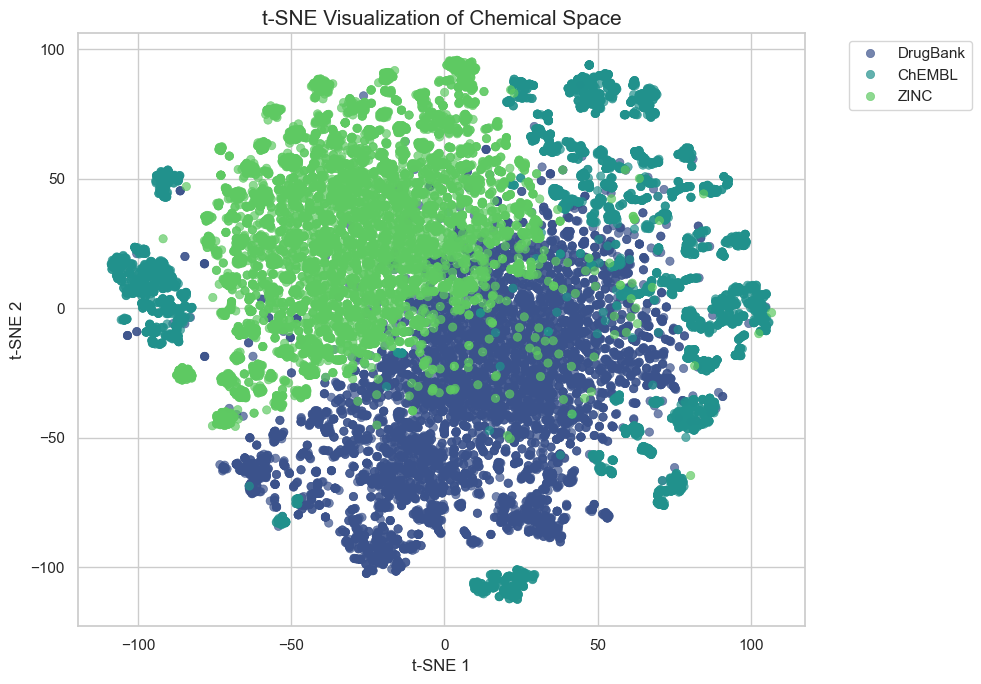

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set_theme(style="whitegrid")

# Create the scatter plot
plt.figure(figsize=(10, 7))
tsne_plot = sns.scatterplot(
    data=df,
    x='tsne_1',
    y='tsne_2',
    hue='Source',      # Colors points by the 'Source' column
    palette='viridis', # High-contrast color palette
    alpha=0.7,         # Transparency for overlapping points
    edgecolor=None
)

# Labeling and layout
plt.title('t-SNE Visualization of Chemical Space', fontsize=15)
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Move legend outside
plt.tight_layout()

plt.show()

Firstly, let's apply K-Means clustering to the t-SNE coordinates to identify potential clusters in the chemical space. We will then visualize these clusters on the t-SNE plot.

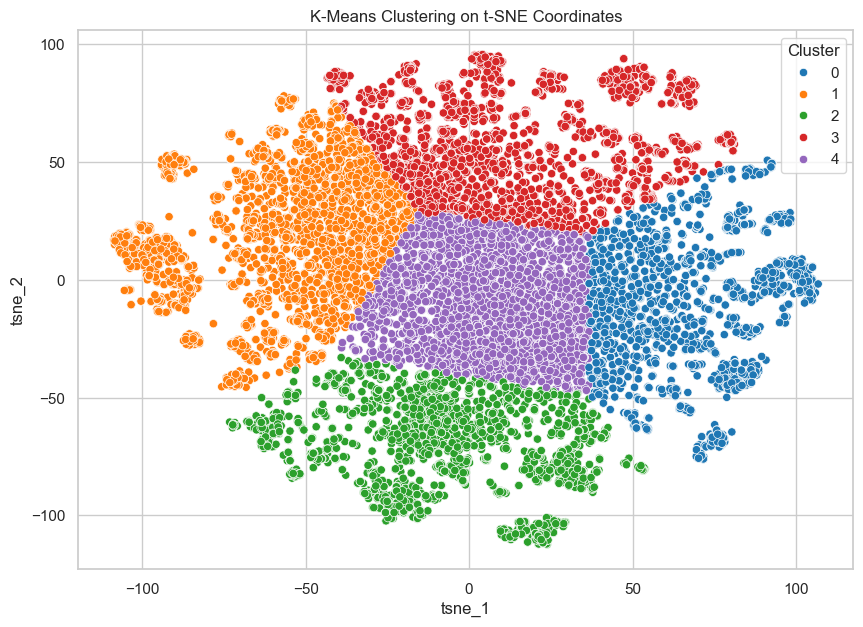

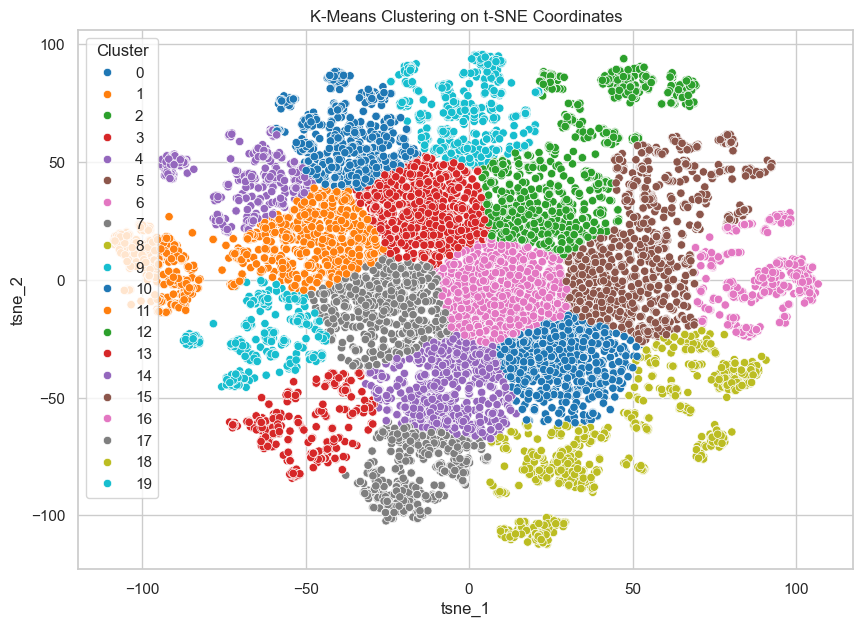

In [12]:
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

def perform_kmeans(n_clusters=5, df=df):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')

    df['Cluster'] = kmeans.fit_predict(df[['tsne_1', 'tsne_2']])

    plt.figure(figsize=(10, 7))
    sns.scatterplot(data=df, x='tsne_1', y='tsne_2', hue='Cluster', palette='tab10')
    plt.title('K-Means Clustering on t-SNE Coordinates')
    plt.show()

perform_kmeans(n_clusters=5)
perform_kmeans(n_clusters=20)

In [5]:
from sklearn.cluster import DBSCAN
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Initialize and fit DBSCAN
# eps: max distance between two samples for one to be considered as in the neighborhood of the other
# min_samples: number of samples in a neighborhood for a point to be a core point
dbscan = DBSCAN(eps=0.5, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(df[['tsne_1', 'tsne_2']])

# Assuming you have already run the DBSCAN code from the previous step:
# 1. Calculate the counts
cluster_counts = df['DBSCAN_Cluster'].value_counts().sort_index()

# 2. Convert to a clean DataFrame for display
summary_table = cluster_counts.reset_index()
summary_table.columns = ['Cluster_ID', 'Participant_Count']

# 3. Print the table
print(summary_table)

# Optional: Identify the number of clusters (excluding noise -1)
n_clusters = len(set(df['DBSCAN_Cluster'])) - (1 if -1 in df['DBSCAN_Cluster'].values else 0)
print(f"\nTotal clusters found (excluding noise): {n_clusters}")

      Cluster_ID  Participant_Count
0             -1               9896
1              0                 12
2              1                  7
3              2                  5
4              3                 14
...          ...                ...
1151        1150                  5
1152        1151                  5
1153        1152                  5
1154        1153                  5
1155        1154                  5

[1156 rows x 2 columns]

Total clusters found (excluding noise): 1155


From DBSCAN we can see that about 10 000 are put in the noise cluster (-1), so they are not part of any dense cluster.


Let's visualize the molecules in a specific cluster.

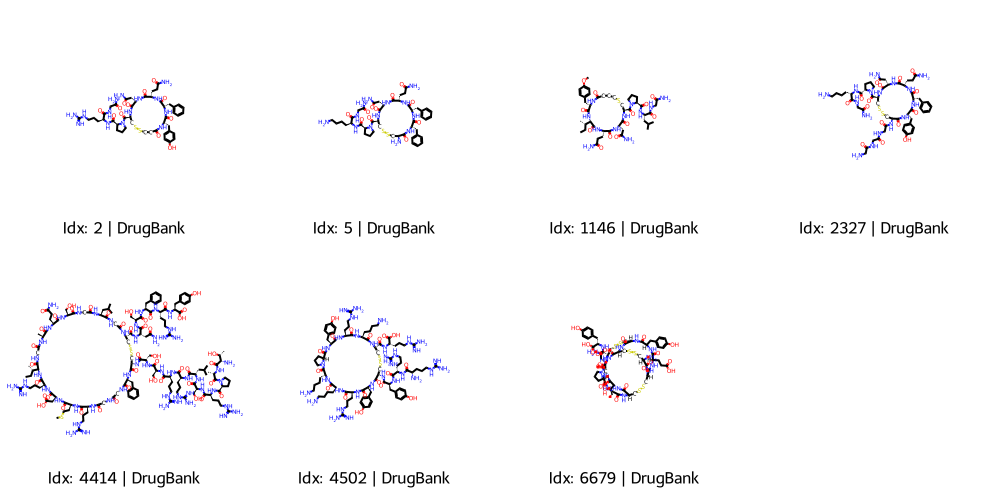

In [20]:
from rdkit import Chem
from rdkit.Chem import Draw

def draw_cluster_molecules(dataframe, cluster_id, cluster_col='DBSCAN_Cluster', smiles_col='Canonical_SMILES', max_mols=20):
    """
    Filters a dataframe by cluster ID and draws molecules with unique legends.
    """
    # 1. Filter and grab the slice to avoid processing more than needed
    cluster_subset = dataframe[dataframe[cluster_col] == cluster_id].head(max_mols)

    mols = []
    legends = []

    # 2. Iterate through rows to maintain link between Mol and its metadata
    for idx, row in cluster_subset.iterrows():
        mol = Chem.MolFromSmiles(row[smiles_col])
        if mol:
            mols.append(mol)
            # Create a unique legend using the DataFrame index and Source
            legend_text = f"Idx: {idx} | {row['Source']}"
            legends.append(legend_text)

    # 3. Generate the grid image
    if not mols:
        print(f"No valid molecules found for Cluster {cluster_id}.")
        return None

    return Draw.MolsToGridImage(
        mols,
        molsPerRow=4,
        subImgSize=(250, 250),
        legends=legends
    )

# Usage:
img = draw_cluster_molecules(df, cluster_id=1)
img

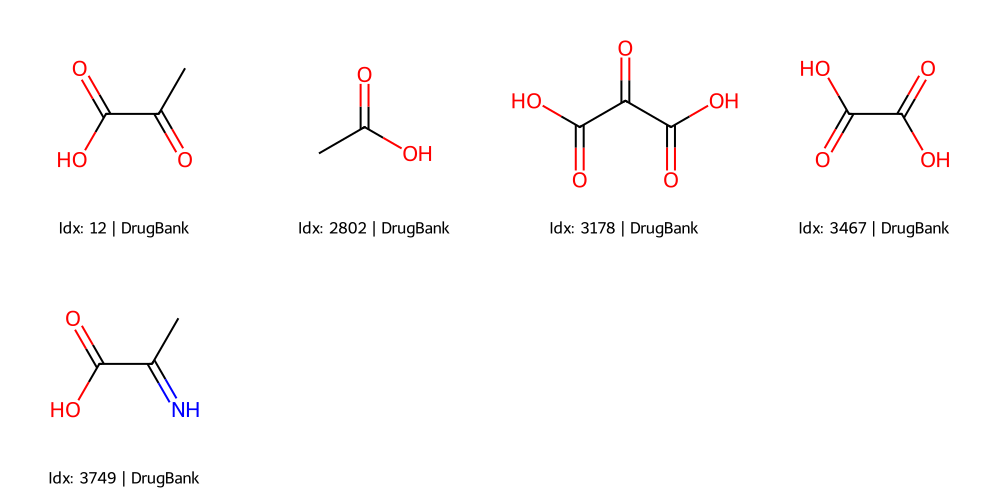

In [21]:
img = draw_cluster_molecules(df, cluster_id=5)
img

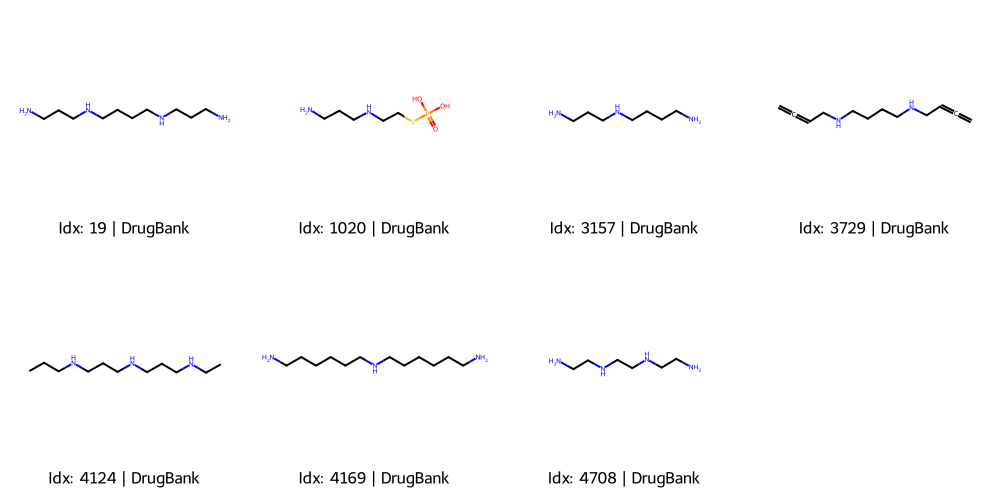

In [22]:
img = draw_cluster_molecules(df, cluster_id=10)
img

Let's try different parameters for DBSCAN and plot the results.

    Cluster_ID  Participant_Count
0           -1                137
1            0              16165
2            1                454
3            2                732
4            3                464
5            4                215
6            5                 98
7            6                148
8            7                146
9            8                261
10           9                 76

Total clusters found (excluding noise): 10


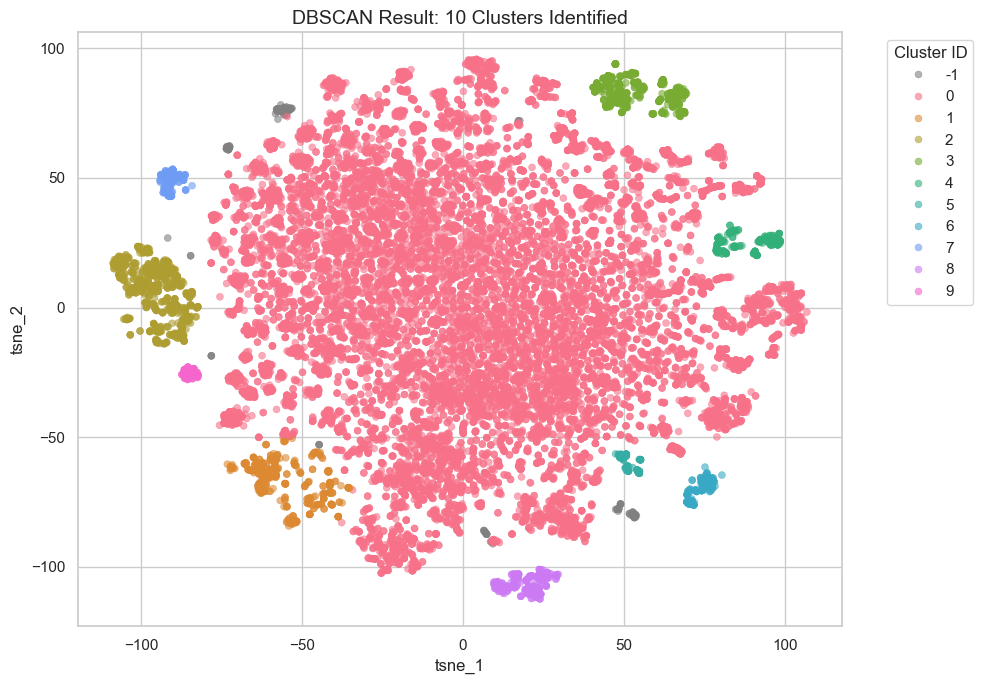

In [31]:
from sklearn.cluster import DBSCAN
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Initialize and fit DBSCAN
dbscan = DBSCAN(eps=7, min_samples=50)
df['DBSCAN_Cluster'] = dbscan.fit_predict(df[['tsne_1', 'tsne_2']])

# 2. Calculate and display summary table
cluster_counts = df['DBSCAN_Cluster'].value_counts().sort_index()
summary_table = cluster_counts.reset_index()
summary_table.columns = ['Cluster_ID', 'Participant_Count']
print(summary_table)

n_clusters = len(set(df['DBSCAN_Cluster'])) - (1 if -1 in df['DBSCAN_Cluster'].values else 0)
print(f"\nTotal clusters found (excluding noise): {n_clusters}")

# 3. Plotting the results
plt.figure(figsize=(10, 7))

# Define a custom palette to make noise (-1) grey
unique_clusters = sorted(df['DBSCAN_Cluster'].unique())
palette = {c: "grey" if c == -1 else sns.color_palette("husl", n_clusters)[list(unique_clusters[1:]).index(c)]
           for c in unique_clusters}

sns.scatterplot(
    data=df,
    x='tsne_1',
    y='tsne_2',
    hue='DBSCAN_Cluster',
    palette=palette,
    alpha=0.6,
    edgecolor=None,
    s=25
)

plt.title(f'DBSCAN Result: {n_clusters} Clusters Identified', fontsize=14)
plt.legend(title='Cluster ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

And let's see one of the clusters again.

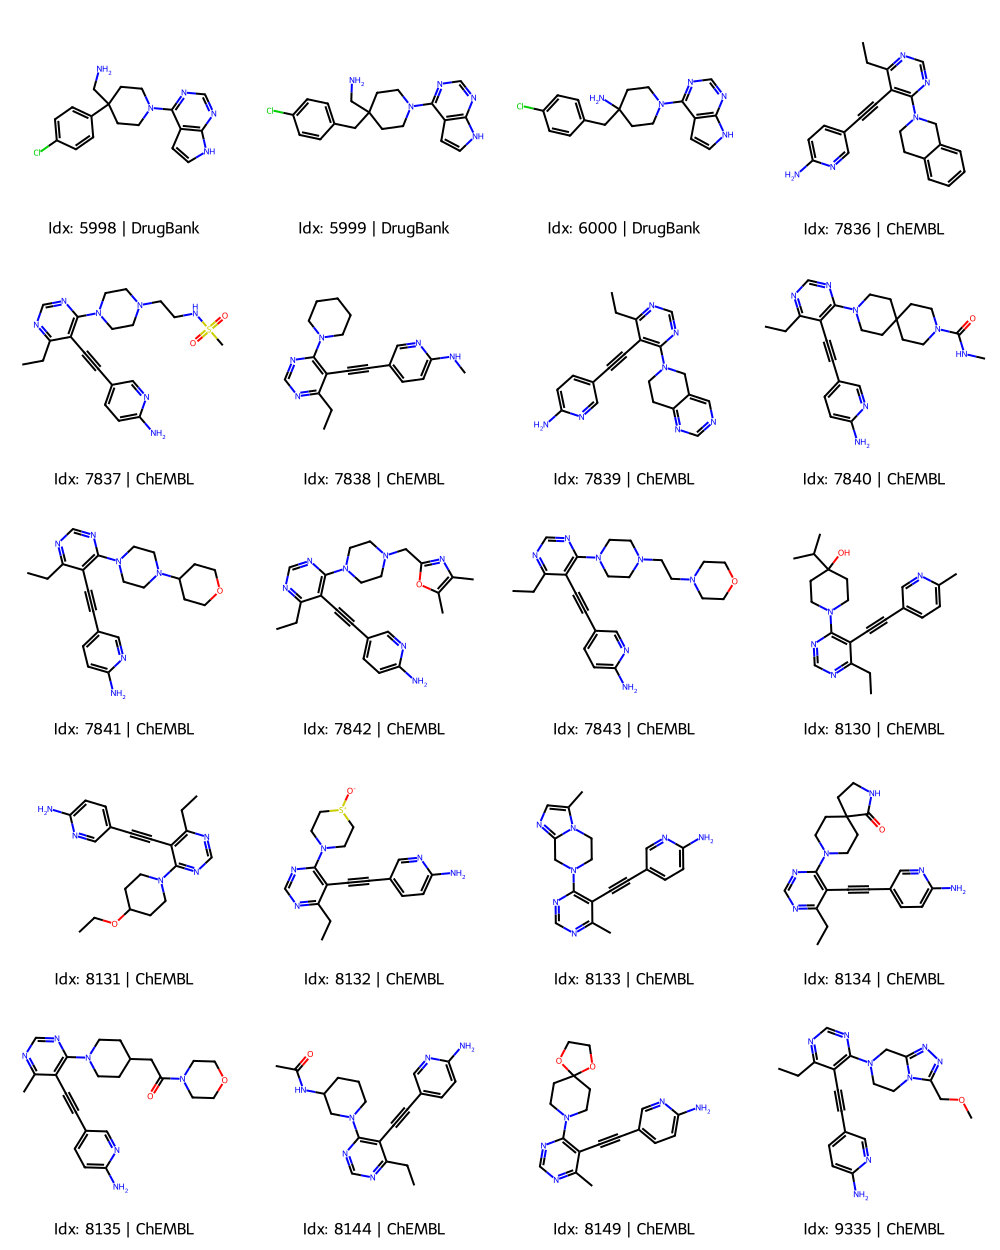

In [40]:
img = draw_cluster_molecules(df, cluster_id=7)
img

Now, we will try

C:\Users\souku\PycharmProjects\cdd2026\.venv\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


     Cluster_ID  Count
0            -1   3451
1             0    146
2             1     79
3             2     21
4             3     15
..          ...    ...
435         434     31
436         435     40
437         436     38
438         437     33
439         438     22

[440 rows x 2 columns]


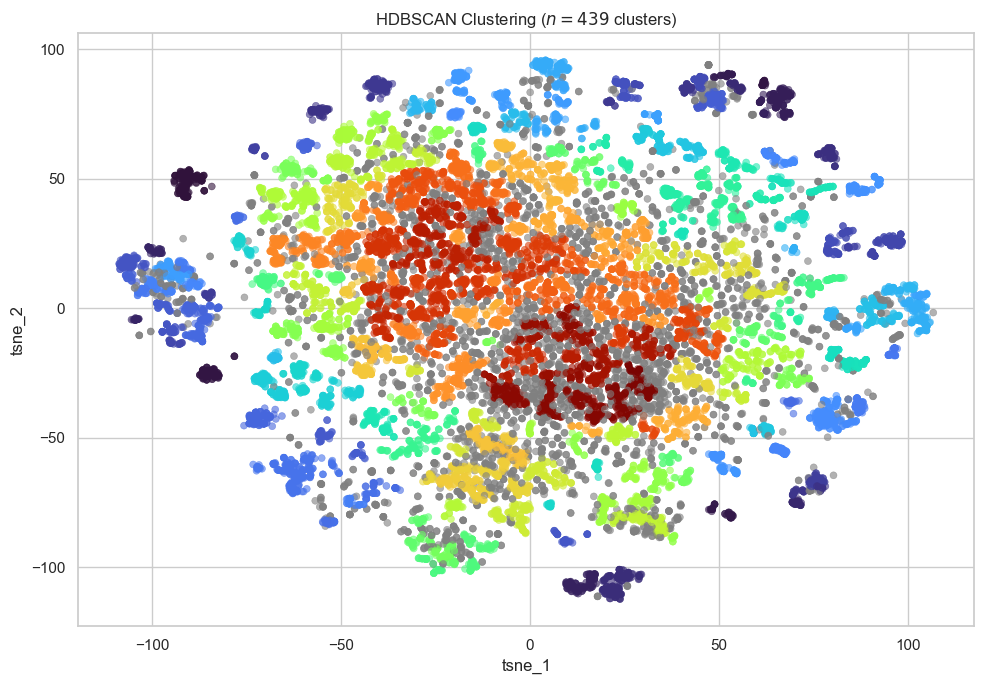

In [42]:
from sklearn.cluster import HDBSCAN
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Fit HDBSCAN
hdbscan_model = HDBSCAN(min_cluster_size=15, min_samples=5)
df['HDBSCAN_Cluster'] = hdbscan_model.fit_predict(df[['tsne_1', 'tsne_2']])

# 2. Summary Table
cluster_counts = df['HDBSCAN_Cluster'].value_counts().sort_index()
print(cluster_counts.rename_axis('Cluster_ID').reset_index(name='Count'))

# 3. Plot without legend
plt.figure(figsize=(10, 7))

# Map noise (-1) to grey
unique_clusters = sorted(df['HDBSCAN_Cluster'].unique())
n_clusters = len(unique_clusters) - (1 if -1 in unique_clusters else 0)
palette = {c: "grey" if c == -1 else sns.color_palette("turbo", n_clusters)[list(unique_clusters).index(c) - (1 if -1 in unique_clusters else 0)]
           for c in unique_clusters}

sns.scatterplot(
    data=df,
    x='tsne_1',
    y='tsne_2',
    hue='HDBSCAN_Cluster',
    palette=palette,
    alpha=0.6,
    edgecolor=None,
    s=25,
    legend=False  # This removes the legend
)

plt.title(f'HDBSCAN Clustering ($n={n_clusters}$ clusters)')
plt.tight_layout()
plt.show()

Let's make it interactive! :DDD

In [43]:
import plotly.express as px

# 1. Prepare a discrete color map for clusters
# This ensures -1 (noise) is always grey, and others use a distinct palette
unique_clusters = sorted(df['HDBSCAN_Cluster'].unique())
n_clusters = len(unique_clusters) - (1 if -1 in unique_clusters else 0)
colors = px.colors.qualitative.Alphabet # High-contrast discrete palette

color_map = {str(c): "lightgrey" if c == -1 else colors[i % len(colors)]
             for i, c in enumerate(unique_clusters)}

# 2. Create the interactive scatter plot
fig = px.scatter(
    df,
    x='tsne_1',
    y='tsne_2',
    color=df['HDBSCAN_Cluster'].astype(str), # Cast to string for discrete colors
    color_discrete_map=color_map,
    hover_data=['Source', 'Canonical_SMILES'], # Shows these on hover
    title=f'Interactive HDBSCAN Clustering ({n_clusters} Clusters)',
    labels={'color': 'Cluster ID'},
    template='plotly_white',
    opacity=0.7
)

# 3. Remove the legend as requested
fig.update_layout(showlegend=False)

# 4. Refine marker size and plot dimensions
fig.update_traces(marker=dict(size=5))
fig.show()

The -1 noise clusters are given in gray. Rest is colorful.

      Cluster_ID  Participant_Count
0              0                  8
1              1                  1
2              2                  4
3              3                  3
4              4                  1
...          ...                ...
5694        5718                  3
5695        5719                  8
5696        5720                  2
5697        5721                  1
5698        5722                  1

[5699 rows x 2 columns]

Total BIRCH clusters found: 5699


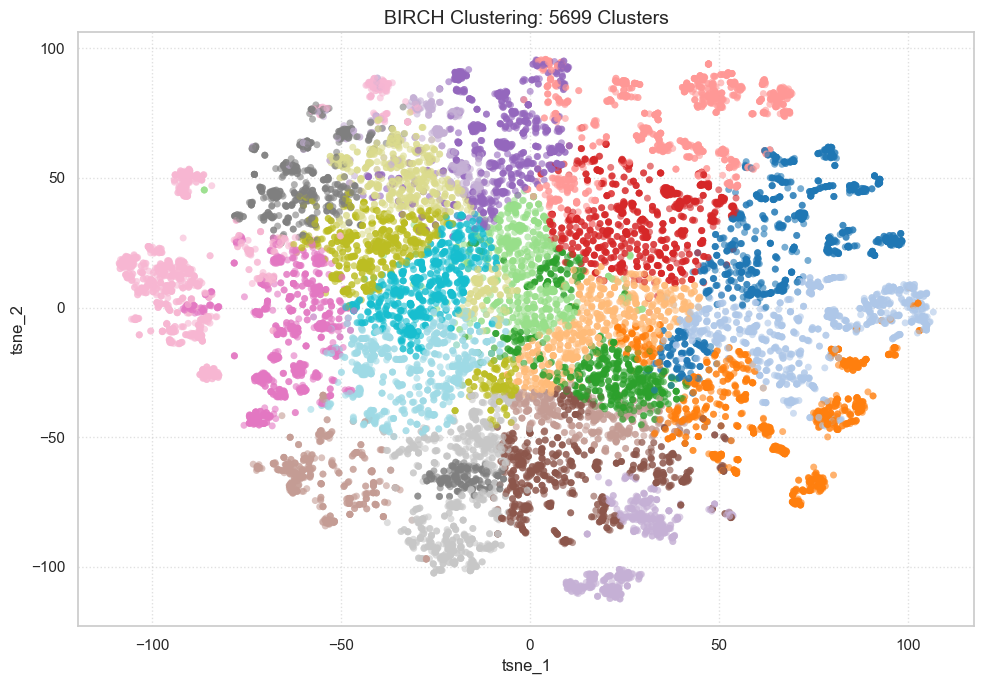

In [44]:
from sklearn.cluster import Birch
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Initialize and fit BIRCH
# threshold: the radius of the subcluster obtained by merging a new sample
# n_clusters: set to None if you want it to find clusters based on threshold, or an int
birch_model = Birch(threshold=0.5, n_clusters=None)
df['BIRCH_Cluster'] = birch_model.fit_predict(df[['tsne_1', 'tsne_2']])

# 2. Calculate counts for the summary table
cluster_counts = df['BIRCH_Cluster'].value_counts().sort_index()
summary_table = cluster_counts.reset_index()
summary_table.columns = ['Cluster_ID', 'Participant_Count']
print(summary_table)

n_clusters = len(summary_table)
print(f"\nTotal BIRCH clusters found: {n_clusters}")

# 3. Classic Matplotlib Plot (No Legend)
plt.figure(figsize=(10, 7))

# Using a colormap to handle many potential clusters
plt.scatter(
    df['tsne_1'],
    df['tsne_2'],
    c=df['BIRCH_Cluster'],
    cmap='tab20',
    alpha=0.6,
    s=25,
    edgecolors='none'
)

plt.title(f'BIRCH Clustering: {n_clusters} Clusters', fontsize=14)
plt.xlabel('tsne_1')
plt.ylabel('tsne_2')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

plt.show()